# Part 2: Pattern Recognition

implement various pattern recognition methods for face classification and clustering.

**Methods covered:**
1. KNN Classification (k=1)
2. GMM Clustering (3 components)
3. SVM Classification (C={0.01, 1, 100})
4. CNN Classification

**Feature extraction methods:**
- Raw vectorized images (1024D)
- PCA transformed features (p=100, 300)
- LDA transformed features (p=10, 20)

In [1]:
# !uv add tensorflow torch

In [2]:
import os
import sys
import numpy as np
import traceback
from typing import Tuple, Dict
from matplotlib import pyplot as plt

#add parent directory to path for imports
sys.path.append('..')

from src.data.data_loader import load_config
from src.preprocessing.pca import compute_pca
from src.models.knn import knn_classify, calculate_accuracy
from src.models.svm import svm_classify
from src.models.cnn import CNNFaceRecognizer
from src.models.gmm import train_gmm, predict_gmm, visualize_clustering_2d

## Load Configuration and Data

In [3]:
config = load_config()
print(f"using seed value: {config['seed']}")

try:
    
    #load training and test data
    x_train = np.load('../Outputs/data/x_train.npy')
    x_test = np.load('../Outputs/data/x_test.npy')
    y_train = np.load('../Outputs/data/y_train.npy')
    y_test = np.load('../Outputs/data/y_test.npy')
    train_selfie_indices = np.load('../Outputs/data/train_selfie_indices.npy')
    test_selfie_indices = np.load('../Outputs/data/test_selfie_indices.npy')
    
    print(f"training data: {x_train.shape}, labels: {y_train.shape}")
    print(f"test data: {x_test.shape}, labels: {y_test.shape}")
    print(f"selfie samples - train: {len(train_selfie_indices)}, test: {len(test_selfie_indices)}")
    
    #create mask for separating pie and selfie test samples
    pie_test_mask = np.ones(len(y_test), dtype=bool)
    pie_test_mask[test_selfie_indices] = False
    
    y_test_pie = y_test[pie_test_mask]
    y_test_selfie = y_test[test_selfie_indices]
    
    print(f"pie test samples: {len(y_test_pie)}, selfie test samples: {len(y_test_selfie)}")
    
except Exception as e:
    print(f"error loading data: {e}")
    print(traceback.format_exc(limit=3))

using seed value: 963
training data: (2978, 1024), labels: (2978,)
test data: (1276, 1024), labels: (1276,)
selfie samples - train: 7, test: 3
pie test samples: 1273, selfie test samples: 3


In [4]:
print(f"selfie data already added to the training set : ")
print(f"Selfie indices in training data : {train_selfie_indices}")
print(f"Selfie training data : {x_train[train_selfie_indices]}")
print(f"Selfie class labels in training data : {y_train[train_selfie_indices]}")

selfie data already added to the training set : 
Selfie indices in training data : [2971 2972 2973 2974 2975 2976 2977]
Selfie training data : [[0.59607846 0.54509807 0.53333336 ... 0.21568628 0.22745098 0.28627452]
 [0.9372549  0.91764706 0.827451   ... 0.78039217 0.7607843  0.76862746]
 [0.9372549  0.9411765  0.94509804 ... 0.93333334 0.93333334 0.93333334]
 ...
 [0.07058824 0.07450981 0.08235294 ... 0.11372549 0.1254902  0.14901961]
 [0.7529412  0.76862746 0.75686276 ... 0.36078432 0.3647059  0.3764706 ]
 [0.5921569  0.59607846 0.59607846 ... 0.45490196 0.5882353  0.6431373 ]]
Selfie class labels in training data : [400 400 400 400 400 400 400]


## Load Precomputed Features

In [5]:
try:
    #load pca features
    x_train_pca_100 = np.load('../Outputs/features/pca_100_features.npy')
    x_train_pca_300 = np.load('../Outputs/features/pca_300_features.npy')
    pca_vectors_100 = np.load('../Outputs/features/pca_100_vectors.npy')
    pca_vectors_300 = np.load('../Outputs/features/pca_300_vectors.npy')
    
    #load lda features
    x_train_lda_10 = np.load('../Outputs/features/lda_10_features.npy')
    x_train_lda_20 = np.load('../Outputs/features/lda_20_features.npy')
    lda_vectors_10 = np.load('../Outputs/features/lda_10_vectors.npy')
    lda_vectors_20 = np.load('../Outputs/features/lda_20_vectors.npy')
    
    #transform test data
    x_test_pca_100 = np.dot(x_test, pca_vectors_100)
    x_test_pca_300 = np.dot(x_test, pca_vectors_300)
    x_test_lda_10 = np.dot(x_test, lda_vectors_10)
    x_test_lda_20 = np.dot(x_test, lda_vectors_20)
    
    print(f"loaded features successfully:")
    print(f"pca-100: train={x_train_pca_100.shape}, test={x_test_pca_100.shape}")
    print(f"pca-300: train={x_train_pca_300.shape}, test={x_test_pca_300.shape}")
    print(f"lda-10: train={x_train_lda_10.shape}, test={x_test_lda_10.shape}")
    print(f"lda-20: train={x_train_lda_20.shape}, test={x_test_lda_20.shape}")
    
except Exception as e:
    print(f"error loading features: {e}")
    print(traceback.format_exc(limit=3))

loaded features successfully:
pca-100: train=(2978, 100), test=(1276, 100)
pca-300: train=(2978, 300), test=(1276, 300)
lda-10: train=(2978, 10), test=(1276, 10)
lda-20: train=(2978, 20), test=(1276, 20)


## KNN Classification
- run on pca features
- run on lda features

In [6]:
def run_knn_classification(x_tr,y_tr,
                           x_te,y_te,
                           method_name,
                           k=1) -> dict[str, any]:
    """
    k nearest neighbors classification with accuracy calculation
    
    Args:
		x_tr: training features
		y_tr: training labels
		x_te: test features
		y_te: test labels
		method_name: name of the feature extraction method
		k: number of neighbors to use in knn
        
    Returns:
		dict: containing predictions and accuracies
    """
    try:
        print(f"running knn on {method_name}...")
        
        y_pred = knn_classify(x_tr, y_tr, x_te, k)
        
        #calculate accuracies
        overall_acc = calculate_accuracy(y_te, y_pred)
        pie_acc = calculate_accuracy(y_test_pie, y_pred[pie_test_mask])
        selfie_acc = calculate_accuracy(y_test_selfie, y_pred[test_selfie_indices])
        
        print(f"{method_name} - overall: {overall_acc:.4f}, pie: {pie_acc:.4f}, selfie: {selfie_acc:.4f}")
        
        return {
            'predictions': y_pred,
            'overall_accuracy': overall_acc,
            'pie_accuracy': pie_acc,
            'selfie_accuracy': selfie_acc
        }
        
    except Exception as e:
        print(f"error in knn {method_name}: {e}")
        print(traceback.format_exc(limit=3))
        return None

In [7]:
#run knn on pca features
knn_results = {}
knn_results['pca_100'] = run_knn_classification(x_train_pca_100,
                                                y_train,
                                                x_test_pca_100,
                                                y_test,
                                                method_name='PCA-100')

knn_results['pca_300'] = run_knn_classification(x_train_pca_300,
                                                y_train,
                                                x_test_pca_300,
                                                y_test,
                                                method_name='PCA-300')

running knn on PCA-100...
PCA-100 - overall: 0.2751, pie: 0.2757, selfie: 0.0000
running knn on PCA-300...
PCA-300 - overall: 0.2790, pie: 0.2797, selfie: 0.0000


In [8]:
#run knn on lda features
knn_results['lda_10'] = run_knn_classification(x_train_lda_10,
												y_train,
												x_test_lda_10,
												y_test,
												method_name='LDA-10')

knn_results['lda_20'] = run_knn_classification(x_train_lda_20,
												y_train,
												x_test_lda_20,
												y_test,
												method_name='LDA-20')

running knn on LDA-10...
LDA-10 - overall: 0.9208, pie: 0.9230, selfie: 0.0000
running knn on LDA-20...
LDA-20 - overall: 0.9522, pie: 0.9544, selfie: 0.0000


## GMM Clustering

### GMM on Raw Images

In [9]:
def run_gmm_clustering(x_tr,
                       x_te,
                       method_name,
                       n_components=3):
    
    """
    run gaussian mixture modelling and return results
    
    Args:
		x_tr: training features
		x_te: test features
		method_name: name of the feature extraction method
		n_components: number of gmm components
        
    Returns:
		dict: containing predicted clusters and gmm model
    """
    try:
        print(f"training gmm on {method_name}...")
        
        gmm = train_gmm(x_tr, n_components, random_state=config['seed'])
        
        test_clusters = predict_gmm(gmm, x_te)
        
        print(f"{method_name} - unique clusters: {np.unique(test_clusters)}")
        
        return {
            'clusters': test_clusters,
            'gmm_model': gmm
        }
        
    except Exception as e:
        print(f"error in gmm {method_name}: {e}")
        print(traceback.format_exc(limit=3))
        return None

#run gmm on raw images
gmm_results = {}
gmm_results['raw'] = run_gmm_clustering(x_train, x_test, 'Raw Images')

training gmm on Raw Images...
Raw Images - unique clusters: [0 1 2]


### GMM on PCA Features

In [10]:
#run gmm on pca features
gmm_results['pca_100'] = run_gmm_clustering(x_train_pca_100,
                                            x_test_pca_100,
                                            'PCA-100')

gmm_results['pca_300'] = run_gmm_clustering(x_train_pca_300,
                                            x_test_pca_300,
                                            'PCA-300')

training gmm on PCA-100...
PCA-100 - unique clusters: [0 1 2]
training gmm on PCA-300...
PCA-300 - unique clusters: [0 1 2]


## SVM Classification

### SVM on Raw Images

In [11]:
def run_svm_classification(x_tr, y_tr,
                           x_te, y_te,
                           method_name,
                           c_values=[0.01, 1, 100]) -> dict[str, any]:
    """
    support vector machine classification with different c values
    
    Args:
		x_tr: training features
		y_tr: training labels
		x_te: test features
		y_te: test labels
		method_name: name of the feature extraction method
		c_values: list of c values to test
        
	Returns:
		dict: containing predictions and accuracies for each c value
    """
    try:
        print(f"running svm on {method_name}...")
        
        results = {}
        
        for c in c_values:
            print(f"  testing c={c}...")
            
            #train svm and predict
            y_pred = svm_classify(x_tr, y_tr, x_te, c=c, random_state=config['seed'])
            
            #calculate accuracies
            train_pred = svm_classify(x_tr, y_tr, x_tr, c=c, random_state=config['seed'])
            train_acc = calculate_accuracy(y_tr, train_pred)
            test_overall_acc = calculate_accuracy(y_te, y_pred)
            test_pie_acc = calculate_accuracy(y_test_pie, y_pred[pie_test_mask])
            test_selfie_acc = calculate_accuracy(y_test_selfie, y_pred[test_selfie_indices])
            
            results[c] = {
                'predictions': y_pred,
                'train_accuracy': train_acc,
                'test_overall_accuracy': test_overall_acc,
                'test_pie_accuracy': test_pie_acc,
                'test_selfie_accuracy': test_selfie_acc
            }
            
            print(f"c={c} - train: {train_acc:.4f} | test: {test_overall_acc:.4f}")
        
        return results
        
    except Exception as e:
        print(f"error in svm {method_name} : {e}")
        print(traceback.format_exc(limit=3))
        return None

#run svm on raw images
svm_results = {}
svm_results['raw'] = run_svm_classification(x_train, y_train, x_test, y_test, 'Raw Images')

running svm on Raw Images...
  testing c=0.01...
c=0.01 - train: 0.8808 | test: 0.8440
  testing c=1...
c=1 - train: 0.9993 | test: 0.9859
  testing c=100...
c=100 - train: 0.9993 | test: 0.9851


### SVM on PCA Features

In [ ]:
#run svm on pca features
svm_results['pca_100'] = run_svm_classification(x_train_pca_100,
                                                y_train,
                                                x_test_pca_100,
                                                y_test,
                                                method_name='PCA-100')

svm_results['pca_300'] = run_svm_classification(x_train_pca_300,
                                                y_train,
                                                x_test_pca_300,
                                                y_test,
                                                method_name='PCA-300')

running svm on PCA-100...
  testing c=0.01...
c=0.01 - train: 0.8690 | test: 0.4028
  testing c=1...
c=1 - train: 0.9983 | test: 0.4020
  testing c=100...
c=100 - train: 0.9993 | test: 0.3942
running svm on PCA-300...
  testing c=0.01...
c=0.01 - train: 0.8788 | test: 0.4020
  testing c=1...
c=1 - train: 0.9990 | test: 0.4373
  testing c=100...
c=100 - train: 0.9993 | test: 0.4342


### SVM on LDA Features

In [ ]:
#run svm on lda features
svm_results['lda_10'] = run_svm_classification(x_train_lda_10,
                                              y_train,
                                              x_test_lda_10,
                                              y_test,
                                              method_name='LDA-10')

running svm on LDA-10...
  testing c=0.01...
c=0.01 - train: 0.0433 | test: 0.0321
  testing c=1...
c=1 - train: 0.1649 | test: 0.1246
  testing c=100...
c=100 - train: 0.9889 | test: 0.9177
running svm on LDA-20...
  testing c=0.01...
c=0.01 - train: 0.0433 | test: 0.0321
  testing c=1...
c=1 - train: 0.2874 | test: 0.2281
  testing c=100...
c=100 - train: 0.9976 | test: 0.9522


## CNN Classification

In [14]:
print(f"selfie data already added to the training set : ")
print(f"Selfie indices in training data : {train_selfie_indices}")
print(f"Selfie training data : {x_train[train_selfie_indices]}")
print(f"Selfie class labels in training data : {y_train[train_selfie_indices]}")

selfie data already added to the training set : 
Selfie indices in training data : [2971 2972 2973 2974 2975 2976 2977]
Selfie training data : [[0.59607846 0.54509807 0.53333336 ... 0.21568628 0.22745098 0.28627452]
 [0.9372549  0.91764706 0.827451   ... 0.78039217 0.7607843  0.76862746]
 [0.9372549  0.9411765  0.94509804 ... 0.93333334 0.93333334 0.93333334]
 ...
 [0.07058824 0.07450981 0.08235294 ... 0.11372549 0.1254902  0.14901961]
 [0.7529412  0.76862746 0.75686276 ... 0.36078432 0.3647059  0.3764706 ]
 [0.5921569  0.59607846 0.59607846 ... 0.45490196 0.5882353  0.6431373 ]]
Selfie class labels in training data : [400 400 400 400 400 400 400]


In [ ]:
# test the label mapping fix first
print("testing label mapping fix...")

# check current label distribution
unique_labels = np.unique(y_train)
print(f"current unique labels: {sorted(unique_labels)}")
print(f"min label: {np.min(y_train)}, max label: {np.max(y_train)}")
print(f"missing labels in 0-25 range: {[i for i in range(26) if i not in unique_labels]}")

# test label mapping functions - map selfie to missing label 7
def fix_labels(y):
    """map label 400 to missing label 7"""
    y_fixed = y.copy()
    y_fixed[y_fixed == 400] = 7  # map selfie label to missing label 7
    return y_fixed

def unfix_labels(y):
    """map label 7 back to 400"""
    y_unfixed = y.copy()
    y_unfixed[y_unfixed == 7] = 400
    return y_unfixed

# apply mapping
y_train_cnn = fix_labels(y_train)
y_test_cnn_labels = fix_labels(y_test)

print(f"after mapping - train unique labels: {sorted(np.unique(y_train_cnn))}")
print(f"after mapping - test unique labels: {sorted(np.unique(y_test_cnn_labels))}")
print(f"number of classes: {len(np.unique(y_train_cnn))}")

cnn_results = None
try:
    print("training tensorflow cnn classifier...")

    #reshape data for cnn (32x32x1)
    x_train_cnn = x_train.reshape(-1, 32, 32, 1)
    x_test_cnn = x_test.reshape(-1, 32, 32, 1)

    #create and train cnn with correct number of classes (26)
    cnn = CNNFaceRecognizer(
        input_shape=(32, 32, 1),
        num_classes=26,  # 25 training + selfie class
        random_state=config['seed']
    )

    #train cnn
    history = cnn.train(
        x_train_cnn, y_train_cnn,
        validation_data=(x_test_cnn, y_test_cnn_labels),
        epochs=50,
        batch_size=32,
        learning_rate=0.001
    )

    #evaluate cnn
    cnn_metrics = cnn.evaluate(x_test_cnn, y_test_cnn_labels)

    #predictions
    y_pred_cnn = cnn.predict(x_test_cnn)

    #map predictions back for comparison (7 -> 400)
    y_pred_cnn_original = unfix_labels(y_pred_cnn)

    #calculate separate accuracies using original labels
    cnn_overall_acc = calculate_accuracy(y_test, y_pred_cnn_original)
    cnn_pie_acc = calculate_accuracy(y_test_pie, y_pred_cnn_original[pie_test_mask])
    cnn_selfie_acc = calculate_accuracy(y_test_selfie, y_pred_cnn_original[test_selfie_indices])

    print(f"tensorflow cnn results - overall: {cnn_overall_acc:.4f}, pie: {cnn_pie_acc:.4f}, selfie: {cnn_selfie_acc:.4f}")
    print(f"final test accuracy: {cnn_metrics.get('accuracy', 0):.4f}")

    cnn_results = {
        'predictions': y_pred_cnn_original,
        'overall_accuracy': cnn_overall_acc,
        'pie_accuracy': cnn_pie_acc,
        'selfie_accuracy': cnn_selfie_acc,
        'training_history': history,
        'test_metrics': cnn_metrics
    }

except Exception as e:
    print(f"tensorflow cnn error: {e}")
    print("falling back to pytorch cnn implementation...")
    
    # fallback to pytorch implementation
    try:
        from src.models.cnn_torch import TorchCNNClassifier
        
        print("training pytorch cnn classifier...")
        
        #reshape data for torch cnn (32x32x1)
        x_train_cnn = x_train.reshape(-1, 32, 32, 1)
        x_test_cnn = x_test.reshape(-1, 32, 32, 1)
        
        #create and train torch cnn
        torch_cnn = TorchCNNClassifier(
            input_shape=(32, 32, 1),
            num_classes=26,  # exactly 26 classes: 0-25
            random_state=config['seed']
        )
        
        #train torch cnn
        history = torch_cnn.train(
            x_train_cnn, y_train_cnn,
            validation_data=(x_test_cnn, y_test_cnn_labels),
            epochs=50,
            batch_size=32,
            learning_rate=0.001
        )
        
        #evaluate torch cnn
        cnn_metrics = torch_cnn.evaluate(x_test_cnn, y_test_cnn_labels)
        
        #predictions
        y_pred_cnn = torch_cnn.predict(x_test_cnn)
        
        #map predictions back for comparison (7 -> 400)
        y_pred_cnn_original = unfix_labels(y_pred_cnn)
        
        #calculate separate accuracies using original labels
        cnn_overall_acc = calculate_accuracy(y_test, y_pred_cnn_original)
        cnn_pie_acc = calculate_accuracy(y_test_pie, y_pred_cnn_original[pie_test_mask])
        cnn_selfie_acc = calculate_accuracy(y_test_selfie, y_pred_cnn_original[test_selfie_indices])
        
        print(f"pytorch cnn results - overall: {cnn_overall_acc:.4f}, pie: {cnn_pie_acc:.4f}, selfie: {cnn_selfie_acc:.4f}")
        print(f"final test accuracy: {cnn_metrics.get('accuracy', 0):.4f}")
        
        cnn_results = {
            'predictions': y_pred_cnn_original,
            'overall_accuracy': cnn_overall_acc,
            'pie_accuracy': cnn_pie_acc,
            'selfie_accuracy': cnn_selfie_acc,
            'training_history': history,
            'test_metrics': cnn_metrics
        }
        
        print("pytorch cnn completed successfully!")
        
    except Exception as e2:
        print(f"pytorch cnn also failed: {e2}")
        print(traceback.format_exc(limit=3))
        cnn_results = None

testing label mapping fix...
current unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(400)]
min label: 0, max label: 400
missing labels in 0-25 range: [7]
after mapping - train unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]
after mapping - test unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64

/Users/aamirsyedaltaf/Documents/ee5026/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2740 - loss: 2.5871 - val_accuracy: 0.6497 - val_loss: 1.2811
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8254 - loss: 0.6814 - val_accuracy: 0.8691 - val_loss: 0.4556
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9228 - loss: 0.2959 - val_accuracy: 0.9397 - val_loss: 0.2467
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9597 - loss: 0.1644 - val_accuracy: 0.9569 - val_loss: 0.1980
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9731 - loss: 0.1070 - val_accuracy: 0.9632 - val_loss: 0.1560
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9799 - loss: 0.0771 - val_accuracy: 0.9647 - val_loss: 0.1521
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9893 - loss: 0.0500 - val_accuracy: 0.9718 - val_loss: 0.1163
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9913 - loss: 0.0398 - val_accuracy: 0.9710 - val_loss: 0.1183


method raw: x_vis shape = (1024, 2), clusters shape = (1276,)
dimension mismatch for raw: x_vis has 1024 samples, clusters has 1276 samples
method pca_100: x_vis shape = (1276, 2), clusters shape = (1276,)
method pca_300: x_vis shape = (1276, 2), clusters shape = (1276,)


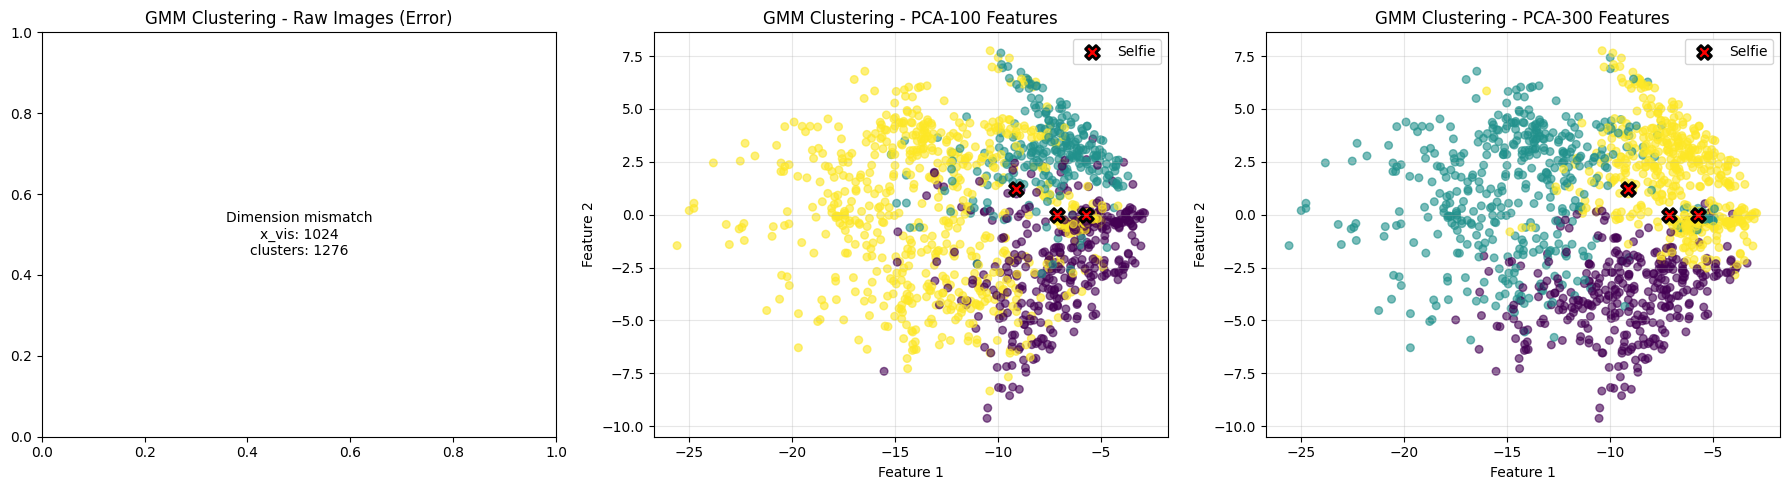

gmm clustering comparison saved


In [16]:
os.makedirs('../Outputs/pattern_recognition', exist_ok=True)
try:
    
    #visualize gmm results
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    methods = ['raw', 'pca_100', 'pca_300']
    titles = ['Raw Images', 'PCA-100 Features', 'PCA-300 Features']
    
    for i, (method, title) in enumerate(zip(methods, titles)):
        if gmm_results[method] is not None:
            #for visualization, reduce to 2d
            if method == 'raw':
                # fix: apply PCA to test data directly, not training data
                pca_vis, _ = compute_pca(x_test, 2)
                x_vis = pca_vis
            elif method == 'pca_100':
                x_vis = x_test_pca_100[:, :2]
            elif method == 'pca_300':
                x_vis = x_test_pca_300[:, :2]
            
            clusters = gmm_results[method]['clusters']
            
            #debug dimensions
            print(f"method {method}: x_vis shape = {x_vis.shape}, clusters shape = {clusters.shape}")
            
            #plot clusters - ensure dimensions match
            if x_vis.shape[0] == clusters.shape[0]:
                scatter = axes[i].scatter(x_vis[:, 0], x_vis[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=30)
                
                #highlight selfie samples
                axes[i].scatter(x_vis[test_selfie_indices, 0], x_vis[test_selfie_indices, 1],
                              c='red', s=100, marker='X', linewidths=2, edgecolors='black', label='Selfie')
                
                axes[i].set_title(f'GMM Clustering - {title}')
                axes[i].set_xlabel('Feature 1')
                axes[i].set_ylabel('Feature 2')
                axes[i].legend()
                axes[i].grid(True, alpha=0.3)
            else:
                print(f"dimension mismatch for {method}: x_vis has {x_vis.shape[0]} samples, clusters has {clusters.shape[0]} samples")
                axes[i].text(0.5, 0.5, f'Dimension mismatch\nx_vis: {x_vis.shape[0]}\nclusters: {clusters.shape[0]}', 
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].set_title(f'GMM Clustering - {title} (Error)')
    
    plt.tight_layout()
    plt.savefig('../Outputs/pattern_recognition/gmm_clustering_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("gmm clustering comparison saved")
    
except Exception as e:
    print(f"error visualizing gmm: {e}")
    print(traceback.format_exc(limit=3))

## Compare Classification Results

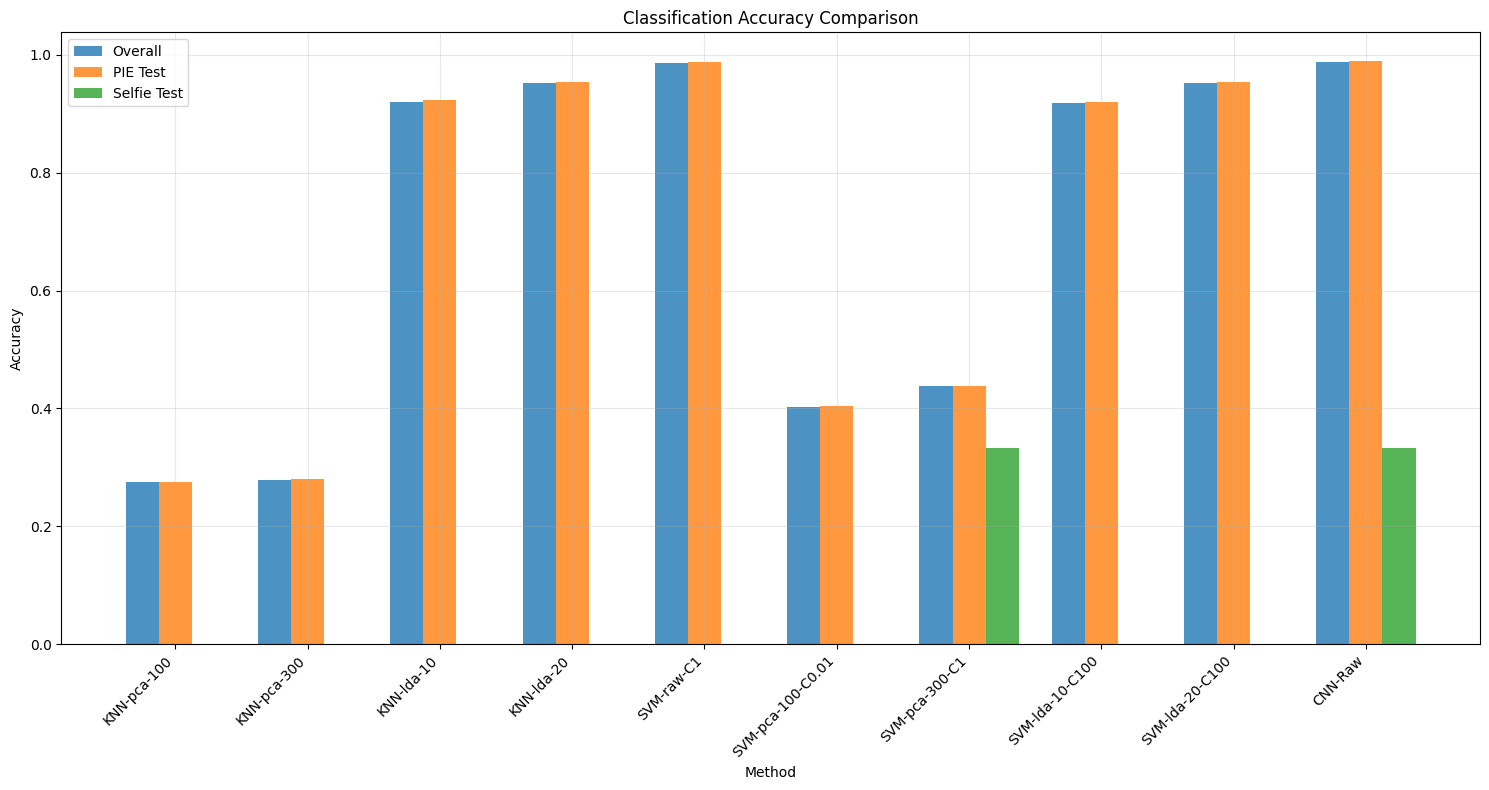

classification accuracy comparison saved


In [17]:
try:
    #collect all classification results
    methods = []
    overall_accs = []
    pie_accs = []
    selfie_accs = []
    
    #knn results
    for method in ['pca_100', 'pca_300', 'lda_10', 'lda_20']:
        if knn_results[method] is not None:
            methods.append(f'KNN-{method.replace("_", "-")}')
            overall_accs.append(knn_results[method]['overall_accuracy'])
            pie_accs.append(knn_results[method]['pie_accuracy'])
            selfie_accs.append(knn_results[method]['selfie_accuracy'])
    
    #svm results (best c value for each method)
    for method in ['raw', 'pca_100', 'pca_300', 'lda_10', 'lda_20']:
        if svm_results[method] is not None:
            #find best c based on test accuracy
            best_c = max(svm_results[method].keys(), 
                       key=lambda c: svm_results[method][c]['test_overall_accuracy'])
            best_result = svm_results[method][best_c]
            
            methods.append(f'SVM-{method.replace("_", "-")}-C{best_c}')
            overall_accs.append(best_result['test_overall_accuracy'])
            pie_accs.append(best_result['test_pie_accuracy'])
            selfie_accs.append(best_result['test_selfie_accuracy'])
    
    #cnn results
    if cnn_results is not None:
        methods.append('CNN-Raw')
        overall_accs.append(cnn_results['overall_accuracy'])
        pie_accs.append(cnn_results['pie_accuracy'])
        selfie_accs.append(cnn_results['selfie_accuracy'])
    
    #create comparison plot
    fig, ax = plt.subplots(figsize=(15, 8))
    
    x = np.arange(len(methods))
    width = 0.25
    
    ax.bar(x - width, overall_accs, width, label='Overall', alpha=0.8)
    ax.bar(x, pie_accs, width, label='PIE Test', alpha=0.8)
    ax.bar(x + width, selfie_accs, width, label='Selfie Test', alpha=0.8)
    
    ax.set_xlabel('Method')
    ax.set_ylabel('Accuracy')
    ax.set_title('Classification Accuracy Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../Outputs/pattern_recognition/classification_accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("classification accuracy comparison saved")
    
except Exception as e:
    print(f"error comparing results: {e}")
    print(traceback.format_exc(limit=3))

## Save All Results

In [18]:
results_dir = '../Outputs/pattern_recognition'
try:
    
    #save knn results
    for method, result in knn_results.items():
        if result is not None:
            np.save(f'{results_dir}/knn_{method}_predictions.npy', result['predictions'])
    
    #save gmm results
    for method, result in gmm_results.items():
        if result is not None:
            np.save(f'{results_dir}/gmm_{method}_clusters.npy', result['clusters'])
    
    #save svm results (best c for each method)
    for method, result_dict in svm_results.items():
        if result_dict is not None:
            best_c = max(result_dict.keys(), 
                       key=lambda c: result_dict[c]['test_overall_accuracy'])
            np.save(f'{results_dir}/svm_{method}_best_predictions.npy', result_dict[best_c]['predictions'])
    
    #save cnn results
    if cnn_results is not None:
        np.save(f'{results_dir}/cnn_predictions.npy', cnn_results['predictions'])
    
    print("all results saved to ../Outputs/pattern_recognition/")
    
except Exception as e:
    print(f"error saving results: {e}")
    print(traceback.format_exc(limit=3))

all results saved to ../Outputs/pattern_recognition/
